In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings(action='ignore')

In [2]:
df=pd.read_excel('k-means.xlsx')

In [3]:
df

,Name,Age,Income
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000
5,Gautam,39,155000
6,David,41,160000
7,Andrea,38,162000
8,Brad,36,156000
9,Angelina,35,130000


In [4]:
df.shape

(22, 3)

Text(0, 0.5, 'Income')

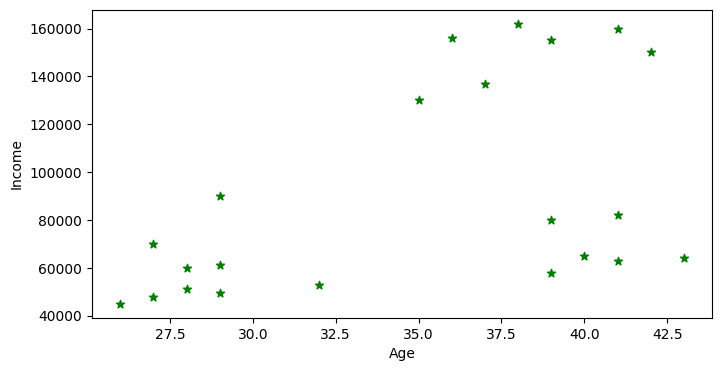

In [5]:
plt.figure(figsize=(8,4))
plt.scatter(df.Age,df.Income,color='Green',marker='*')
plt.xlabel('Age')
plt.ylabel('Income')

In [6]:
from sklearn.cluster import KMeans
model=KMeans(n_clusters=3)

In [7]:
y_pred=model.fit_predict(df[['Age','Income']])

In [8]:
y_pred

array([2, 2, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0],
      dtype=int32)

In [9]:
df['Cluster']=y_pred

In [10]:
df

,Name,Age,Income,Cluster
0,Rob,27,70000,2
1,Michael,29,90000,2
2,Mohan,29,61000,0
3,Ismail,28,60000,0
4,Kory,42,150000,1
5,Gautam,39,155000,1
6,David,41,160000,1
7,Andrea,38,162000,1
8,Brad,36,156000,1
9,Angelina,35,130000,1


In [11]:
df1=df[df.Cluster==0]
df2=df[df.Cluster==1]
df3=df[df.Cluster==2]

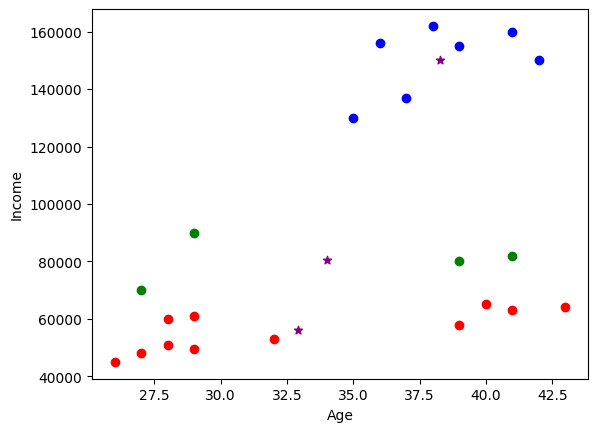

In [12]:
plt.scatter(df1.Age,df1.Income,color='red')
plt.scatter(df2.Age,df2.Income,color='blue')
plt.scatter(df3.Age,df3.Income,color='green')
plt.scatter(model.cluster_centers_[:,0],model.cluster_centers_[:,1],color='purple',marker='*',label="Centroid")
plt.xlabel('Age')
plt.ylabel('Income')
plt.show()

In [13]:
sse=[]
k_range=range(1,10)
for k in range(1,10):
    km=KMeans(n_clusters=k)
    km.fit(df[['Age','Income']])
    sse.append(km.inertia_)

In [14]:
sse

[39748148458.54546,
 3318233941.161905,
 1606229737.6785712,
 814746044.2545456,
 296500418.0952381,
 242050408.29523808,
 185333590.6666667,
 130883580.86666667,
 95133611.78333333]

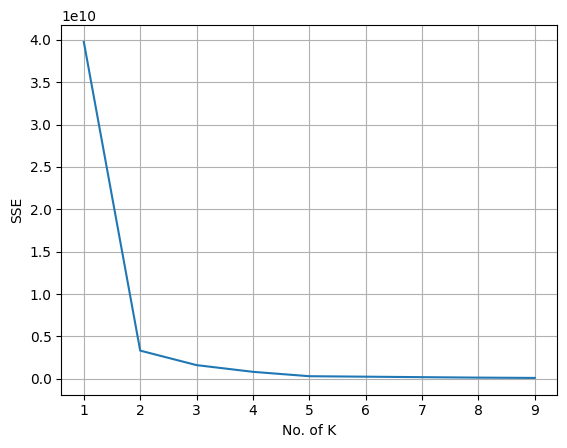

In [15]:
plt.xlabel('No. of K')
plt.ylabel('SSE')
plt.plot(k_range,sse)
plt.grid(True)
plt.show()

In [16]:
from sklearn.metrics import silhouette_score

In [17]:
silhouette_score(df[['Age','Income']],df['Cluster'])

0.6555650934726583

In [18]:
model2=KMeans(n_clusters=2)

In [19]:
y_pred2=model2.fit_predict(df[['Age','Income']])

In [20]:
y_pred2

array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
      dtype=int32)

In [21]:
df['Cluster2']=y_pred2

In [22]:
df

,Name,Age,Income,Cluster,Cluster2
0,Rob,27,70000,2,0
1,Michael,29,90000,2,0
2,Mohan,29,61000,0,0
3,Ismail,28,60000,0,0
4,Kory,42,150000,1,1
5,Gautam,39,155000,1,1
6,David,41,160000,1,1
7,Andrea,38,162000,1,1
8,Brad,36,156000,1,1
9,Angelina,35,130000,1,1


In [23]:
df11=df[df.Cluster2==0]
df21=df[df.Cluster2==1]


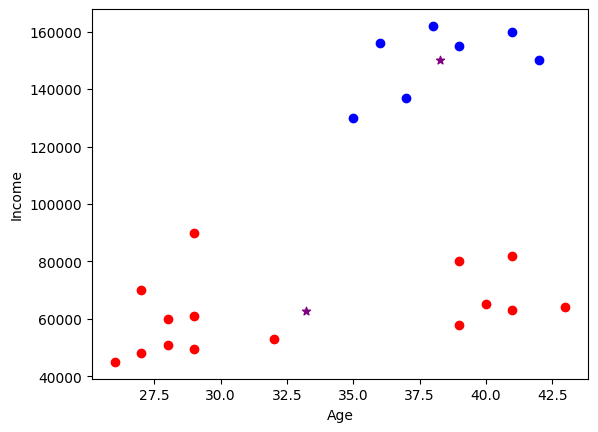

In [24]:
plt.scatter(df11.Age,df11.Income,color='red')
plt.scatter(df21.Age,df21.Income,color='blue')
plt.scatter(model2.cluster_centers_[:,0],model2.cluster_centers_[:,1],color='purple',marker='*',label="Centroid")
plt.xlabel('Age')
plt.ylabel('Income')
plt.show()

In [25]:
silhouette_score(df[['Age','Income']],df['Cluster2'])

0.8191238627089519